🚀 [5/7] KNN 訓練開始 (單核保護)...
   ⚠️ 訓練集降取樣至 15000 筆以防當機 (原 42547 筆)...
✅ Accuracy: 0.5933
                  precision    recall  f1-score   support

      feel_angry       0.54      0.66      0.60       635
     feel_boring       0.44      0.47      0.46       285
 feel_depressing       0.56      0.60      0.58       320
      feel_happy       0.55      0.51      0.53       978
feel_informative       0.67      0.71      0.69      1979
        feel_odd       0.46      0.26      0.33       295
       feel_warm       0.62      0.32      0.42       181
    feel_worried       0.65      0.44      0.52        55

        accuracy                           0.59      4728
       macro avg       0.56      0.50      0.52      4728
    weighted avg       0.59      0.59      0.59      4728



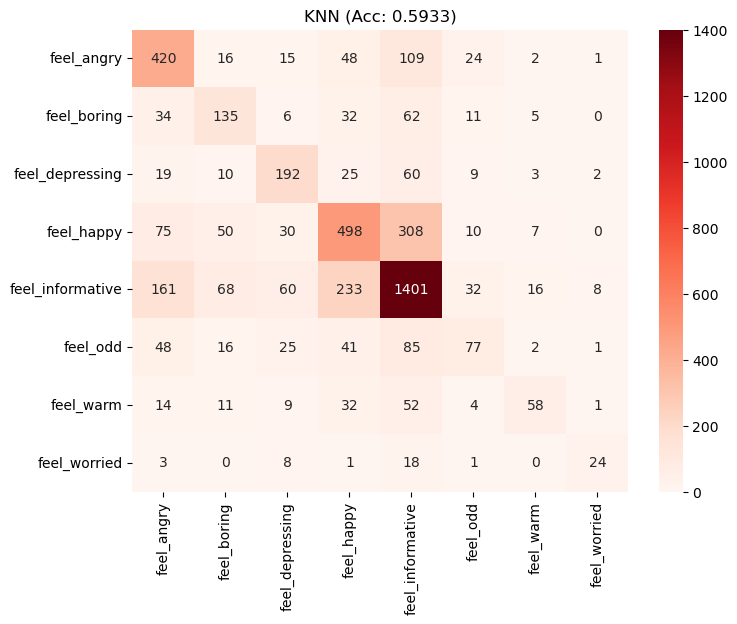

In [1]:
# 5_KNN.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

if __name__ == '__main__':
    print("🚀 [5/7] KNN 訓練開始 (單核保護)...")
    
    df = pd.read_csv('Processed_Data.csv')
    df['text_segmented'] = df['text_segmented'].fillna('')
    X_text = df['text_segmented'].values
    y_raw = df['Column1'].values

    vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True, dtype=np.float32)
    X_tfidf = vectorizer.fit_transform(X_text)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(X_tfidf))
    X_train, X_test = X_tfidf[train_idx], X_tfidf[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    # KNN 記憶體保護：若訓練集太大，進行降取樣
    if X_train.shape[0] > 15000:
        print(f"   ⚠️ 訓練集降取樣至 15000 筆以防當機 (原 {X_train.shape[0]} 筆)...")
        np.random.seed(42)
        idx = np.random.choice(X_train.shape[0], 15000, replace=False)
        X_train = X_train[idx]
        y_train = y_train[idx]

    model = KNeighborsClassifier(n_neighbors=5, n_jobs=1) # 強制單核
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'KNN (Acc: {acc:.4f})')
    plt.show()